# Part III - Language Task

This notebook covers tweet preprocessing, sequence models, model comparison, error analysis, and test prediction.


In [56]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')




DATA_DIR = Path('/content/drive/MyDrive/7. Racist Sexist or Not Dataset')
TRAIN_CSV = DATA_DIR / 'train_racisit.csv'
TEST_CSV = DATA_DIR / 'test_racisit.csv'

print("Train file exists:", TRAIN_CSV.exists())
print("Test file exists:", TEST_CSV.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train file exists: True
Test file exists: True


In [57]:
%pip install gensim


In [58]:
from pathlib import Path
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall

import gensim.downloader as api

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Task 1 - Load dataset

This section loads the labeled and unlabeled tweet files.


In [59]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df["label"].value_counts())
train_df.head()


Train shape: (31962, 3)
Test shape: (17197, 2)
label
0    29720
1     2242
Name: count, dtype: int64


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


## Task 2 - Text cleaning

This section builds the text cleaning steps used before tokenization.


In [60]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def lower_order(text):
    return str(text).lower()

def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def removeunwanted_characters(text):








    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def remove_stopwords(tokens):
    return [token for token in tokens if token not in stop_words]

def lemmatization(tokens):
    return [lemmatizer.lemmatize(token, pos="v") for token in tokens]

def text_cleaning_pipeline(text):
    text = lower_order(text)
    text = remove_urls(text)
    text = removeunwanted_characters(text)
    tokens = text.split()
    tokens = remove_stopwords(tokens)
    tokens = lemmatization(tokens)
    return " ".join(tokens)


In [61]:
train_df["clean_text"] = train_df["tweet"].apply(text_cleaning_pipeline)
test_df["clean_text"] = test_df["tweet"].apply(text_cleaning_pipeline)

train_df = train_df[train_df["clean_text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["clean_text"].str.len() > 0].reset_index(drop=True)

train_df[["tweet", "clean_text", "label"]].head()


,tweet,clean_text,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thank #lyft credit can't use cause offer wheel...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,#model love u take u time urð±!!! ððð...,0
4,factsguide: society now #motivation,factsguide: society #motivation,0


## Task 3 - Common words after cleaning

This section shows the most frequent words after preprocessing.


In [62]:
all_words = " ".join(train_df["clean_text"]).split()
word_counts = Counter(all_words).most_common(20)

top_words_df = pd.DataFrame(word_counts, columns=["word", "count"])
top_words_df


,word,count
0,get,1759
1,&amp;,1575
2,day,1454
3,#love,1449
4,happy,1328
5,love,1306
6,go,1261
7,-,1245
8,make,1164
9,u,1116


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


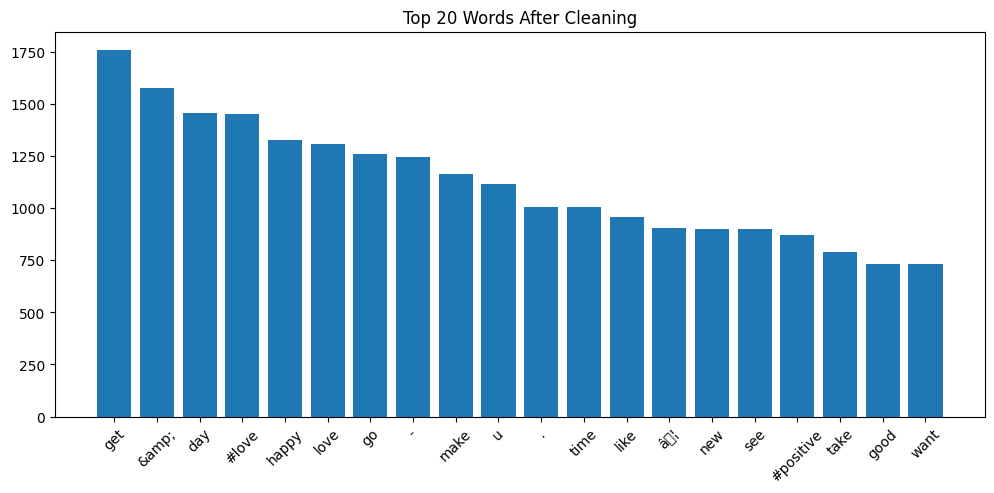

In [63]:
plt.figure(figsize=(12, 5))
plt.bar(top_words_df["word"], top_words_df["count"])
plt.xticks(rotation=45)
plt.title("Top 20 Words After Cleaning")
plt.show()


## Task 4 - Train and test split

This section splits the labeled data into training and testing sets.


In [64]:
X = train_df["clean_text"]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 25563
Testing samples: 6391


## Task 5 - Tokenization and padding

This section converts text into sequences and pads them to the same length.


In [65]:
max_words = 30000
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
unlabeled_test_seq = tokenizer.texts_to_sequences(test_df["clean_text"])

sequence_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(sequence_lengths, 95))
max_len = max(max_len, 60)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")
unlabeled_test_pad = pad_sequences(unlabeled_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("Vocabulary size:", vocab_size)
print("Sequence length:", max_len)


Vocabulary size: 30000
Sequence length: 60


## Task 6 - SimpleRNN model

This section builds and trains the SimpleRNN model.


In [66]:
simple_rnn_model = keras.Sequential([
    keras.Input(shape=(max_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    layers.SimpleRNN(64),
    layers.Dense(1, activation="sigmoid"),
], name="simple_rnn_model")

simple_rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
    Precision(name="precision"),
    Recall(name="recall")
],
)

simple_rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "simple_rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,852,417 (14.70 MB)

 Trainable params: 3,852,417 (14.70 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
simple_rnn_history = simple_rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ModelCheckpoint("final/models/simple_rnn_best.keras", monitor="val_loss", save_best_only=True),
    ],
)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9281 - loss: 0.2587 - precision: 0.1562 - recall: 0.0056 - val_accuracy: 0.9299 - val_loss: 0.2545 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9298 - loss: 0.2550 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2552 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9298 - loss: 0.2550 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2542 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9298 - loss: 0.2551 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2541 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9298 - loss: 0.2547 - precision: 0.0

In [68]:
simple_rnn_probs = simple_rnn_model.predict(X_test_pad)
simple_rnn_pred = (simple_rnn_probs > 0.3).astype("int32")

print("SimpleRNN Accuracy:", accuracy_score(y_test, simple_rnn_pred))
print(classification_report(y_test, simple_rnn_pred, zero_division=0))


200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
SimpleRNN Accuracy: 0.9299014238773274
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5943
           1       0.00      0.00      0.00       448

    accuracy                           0.93      6391
   macro avg       0.46      0.50      0.48      6391
weighted avg       0.86      0.93      0.90      6391



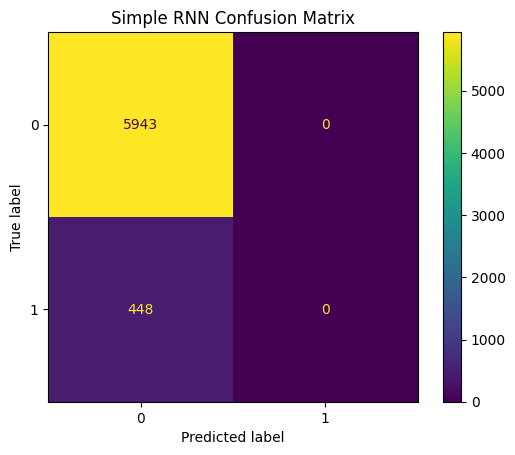

In [87]:
cm = confusion_matrix(y_test, simple_rnn_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Simple RNN Confusion Matrix")
plt.show()


## Task 7 - LSTM model

This section builds and trains the LSTM model.


In [69]:
lstm_model = keras.Sequential([
    keras.Input(shape=(max_len,)),

    layers.Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_len
    ),

    layers.Bidirectional(
        layers.LSTM(128, dropout=0.3)
    ),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
], name = "lstm_model")
lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
    Precision(name="precision"),
    Recall(name="recall")
],
)

lstm_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,119,681 (15.72 MB)

 Trainable params: 4,119,681 (15.72 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = {
    0: 1.0,
    1: 3.0
}

print(class_weights)


{0: 1.0, 1: 3.0}


In [71]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop]
)


Epoch 1/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9368 - loss: 0.3403 - precision: 0.5580 - recall: 0.4548 - val_accuracy: 0.9581 - val_loss: 0.1181 - val_precision: 0.7429 - val_recall: 0.6376
Epoch 2/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9733 - loss: 0.1282 - precision: 0.7851 - recall: 0.8500 - val_accuracy: 0.9632 - val_loss: 0.1132 - val_precision: 0.7640 - val_recall: 0.7057
Epoch 3/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9911 - loss: 0.0460 - precision: 0.9220 - recall: 0.9523 - val_accuracy: 0.9460 - val_loss: 0.1606 - val_precision: 0.5991 - val_recall: 0.7493
Epoch 4/10
640/640 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9964 - loss: 0.0169 - precision: 0.9643 - recall: 0.9846 - val_accuracy: 0.9617 - val_loss: 0.1965 - val_precision: 0.8178 - val_recall: 0.5995


In [72]:
lstm_probs = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_probs > 0.3).astype("int32")

print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))
print(classification_report(y_test, lstm_pred, zero_division=0))


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
LSTM Accuracy: 0.953841339383508
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      5943
           1       0.66      0.70      0.68       448

    accuracy                           0.95      6391
   macro avg       0.82      0.84      0.83      6391
weighted avg       0.96      0.95      0.95      6391



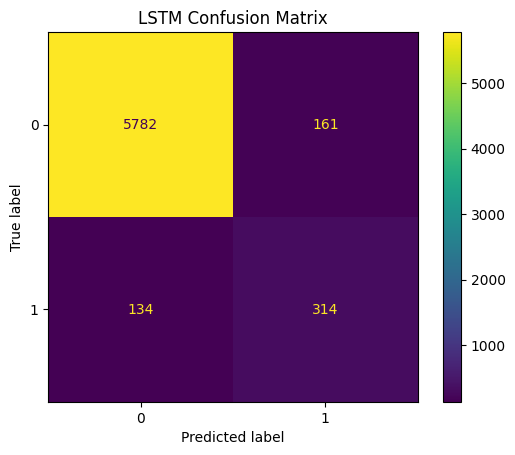

In [86]:
cm = confusion_matrix(y_test, lstm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("LSTM Confusion Matrix")
plt.show()


## Task 8 - LSTM with pretrained Word2Vec

This section builds the embedding matrix and trains the Word2Vec-based LSTM model.


In [73]:
embedding_model = api.load("glove-wiki-gigaword-50")
embedding_dim = 50

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)


Embedding matrix shape: (30000, 50)


In [74]:
lstm_word2vec_model = keras.Sequential([
    keras.Input(shape=(max_len,)),
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True,
    ),
    layers.LSTM(64),
    layers.Dense(1, activation="sigmoid"),
], name="lstm_word2vec_model")

lstm_word2vec_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
    Precision(name="precision"),
    Recall(name="recall")
],
)

lstm_word2vec_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "lstm_word2vec_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 60, 50)         │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,529,505 (5.83 MB)

 Trainable params: 1,529,505 (5.83 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
lstm_word2vec_history = lstm_word2vec_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        ModelCheckpoint("final/models/lstm_word2vec_best.keras", monitor="val_loss", save_best_only=True),
    ],
)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9290 - loss: 0.2614 - precision: 0.1071 - recall: 0.0017 - val_accuracy: 0.9299 - val_loss: 0.2543 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9298 - loss: 0.2548 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2543 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9298 - loss: 0.2545 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2544 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9298 - loss: 0.2546 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9299 - val_loss: 0.2540 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9298 - loss: 0.2546 - precision: 0.0

In [76]:
lstm_word2vec_probs = lstm_word2vec_model.predict(X_test_pad)
lstm_word2vec_pred = (lstm_word2vec_probs > 0.3).astype("int32")

print("LSTM + Word2Vec Accuracy:", accuracy_score(y_test, lstm_word2vec_pred))
print(classification_report(y_test, lstm_word2vec_pred, zero_division=0))


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM + Word2Vec Accuracy: 0.9299014238773274
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5943
           1       0.00      0.00      0.00       448

    accuracy                           0.93      6391
   macro avg       0.46      0.50      0.48      6391
weighted avg       0.86      0.93      0.90      6391



## Task 9 - Model comparison

This section compares the results of the three models.


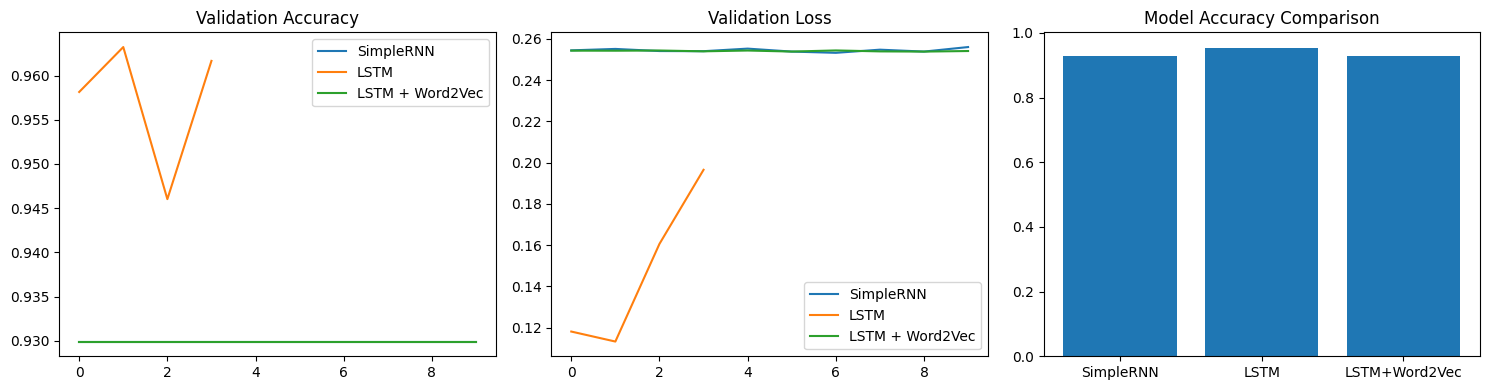

In [77]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(simple_rnn_history.history["val_accuracy"], label="SimpleRNN")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM")
plt.plot(lstm_word2vec_history.history["val_accuracy"], label="LSTM + Word2Vec")
plt.title("Validation Accuracy")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(simple_rnn_history.history["val_loss"], label="SimpleRNN")
plt.plot(lstm_history.history["val_loss"], label="LSTM")
plt.plot(lstm_word2vec_history.history["val_loss"], label="LSTM + Word2Vec")
plt.title("Validation Loss")
plt.legend()

plt.subplot(1, 3, 3)
model_names = ["SimpleRNN", "LSTM", "LSTM+Word2Vec"]
model_acc = [
    accuracy_score(y_test, simple_rnn_pred),
    accuracy_score(y_test, lstm_pred),
    accuracy_score(y_test, lstm_word2vec_pred),
]
plt.bar(model_names, model_acc)
plt.title("Model Accuracy Comparison")

plt.tight_layout()
plt.show()


In [78]:
best_pred = lstm_word2vec_pred
best_prob = lstm_word2vec_probs

analysis_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": best_pred.flatten(),
    "pred_score": best_prob.flatten(),
})

wrong_df = analysis_df[analysis_df["true_label"] != analysis_df["pred_label"]]
wrong_df.head(3)


,text,true_label,pred_label,pred_score
0,"like , #waronwomen, &amp; #guncontrol need #ru...",1,0,0.069944
1,come #powerhungrytraitors. #hereticfoundation!,1,0,0.069943
10,1. lmfao. no. non-white people #bigots #prejud...,1,0,0.069944


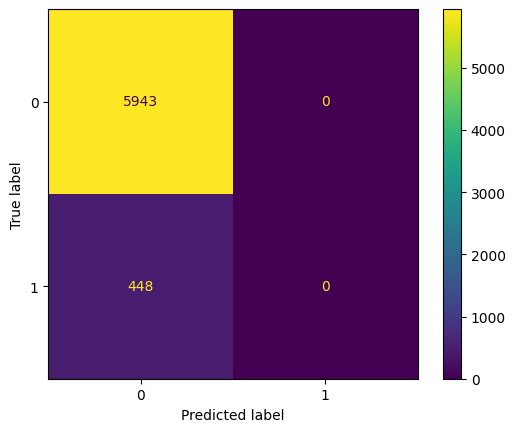

In [84]:
cm = confusion_matrix(y_test, lstm_word2vec_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


## Task 10 - Predict labels for test data

This section predicts labels for the unlabeled test file.


In [80]:
unlabeled_probs = lstm_word2vec_model.predict(unlabeled_test_pad)
unlabeled_pred = (unlabeled_probs > 0.3).astype("int32")

submission_df = pd.DataFrame({
    "id": test_df["id"],
    "label": unlabeled_pred.flatten(),
})

submission_df.head()


538/538 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,id,label
0,31963,0
1,31964,0
2,31965,0
3,31966,0
4,31967,0


In [81]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12,5))


    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()


    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


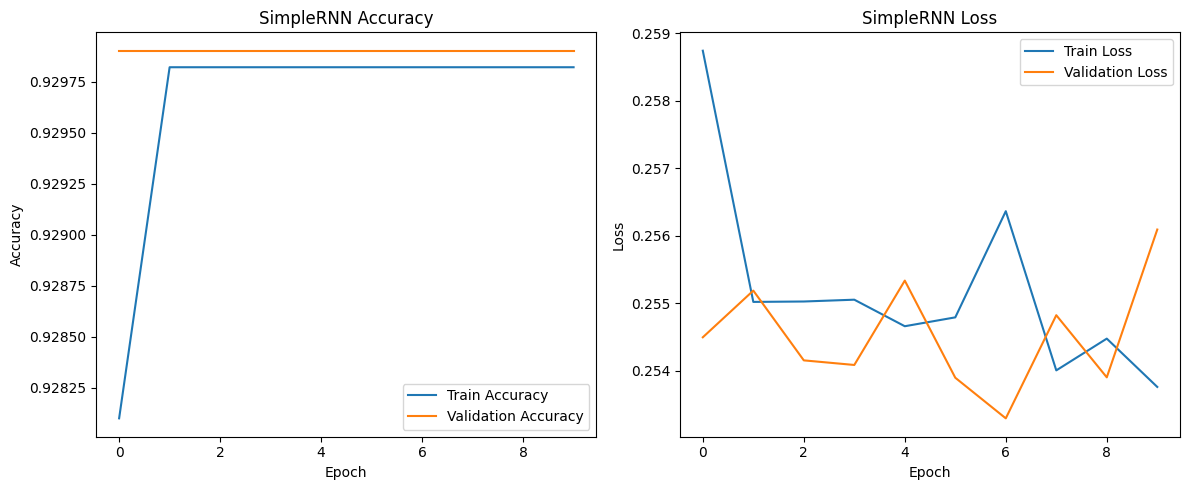

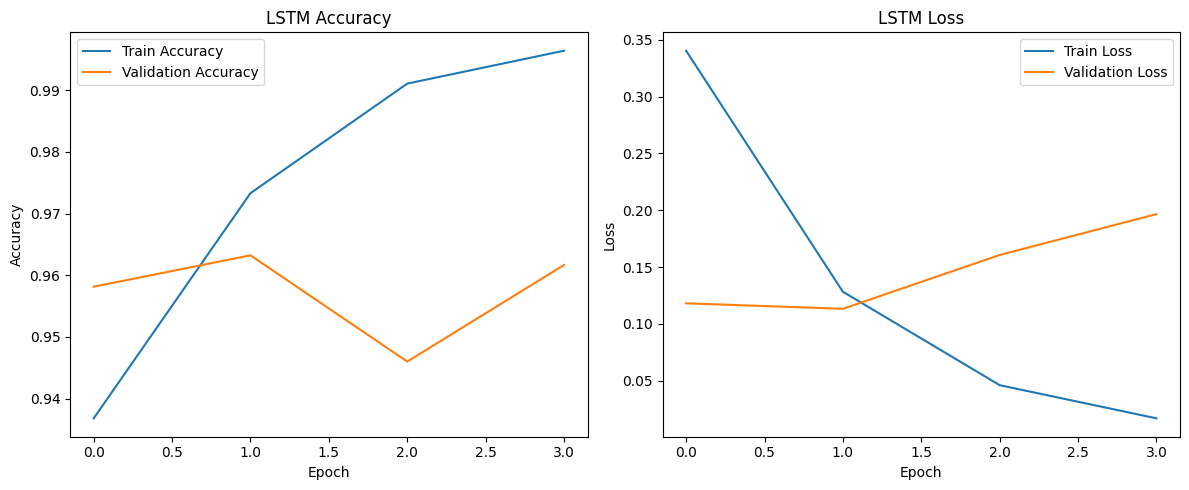

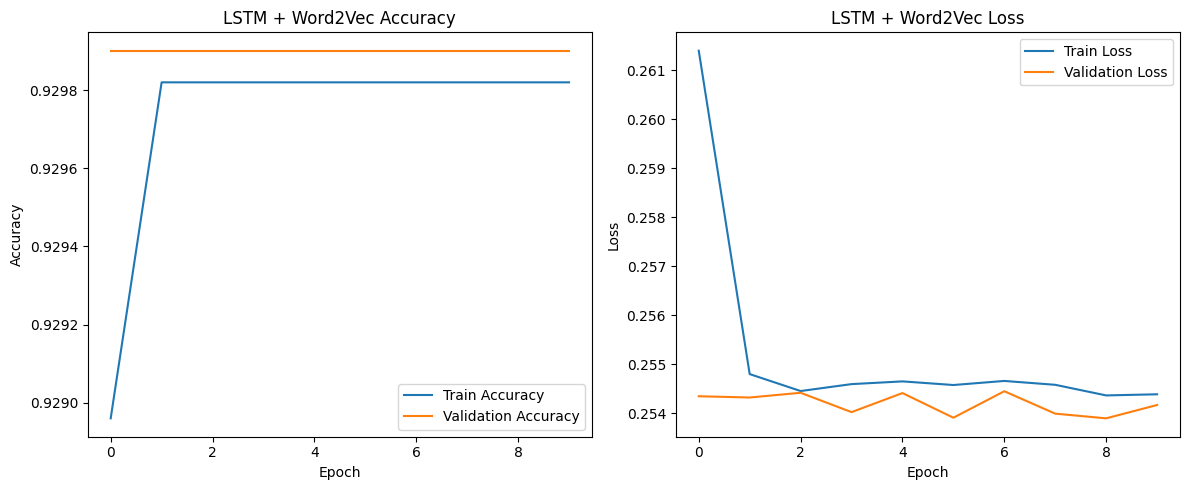

In [82]:
plot_history(simple_rnn_history, "SimpleRNN")
plot_history(lstm_history, "LSTM")
plot_history(lstm_word2vec_history, "LSTM + Word2Vec")


In [88]:
import gradio as gr

def predict_tweet(tweet):
    cleaned = text_cleaning_pipeline(tweet)

    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    prob = lstm_model.predict(pad)[0][0]

    label = "Racist/Sexist" if prob > 0.3 else "Not Racist/Sexist"

    return f"{label} ({prob:.2f})"

demo = gr.Interface(
    fn=predict_tweet,
    inputs="text",
    outputs="text",
    title="Tweet Classification"
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c7ab36cc4419b10df7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
